In [18]:
import pandas as pd
df = pd.read_csv('/content/100_Unique_QA_Dataset.csv')
df.head(3)

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee


In [19]:
# Preprocess and tokenize text
def tokenize(text):
  text = text.lower()
  text = text.replace('?', '')
  text = text.replace("'", "")
  return text.split()

In [20]:
tokenize("What is the capital of France?")

['what', 'is', 'the', 'capital', 'of', 'france']

In [21]:
# Build vocabulary
vocab = {'<UNK>':0}

def build_vocab(row):
  tokenized_question = tokenize(row['question'])
  tokenized_answer = tokenize(row['answer'])
  merged_tokens = tokenized_question + tokenized_answer

  for token in merged_tokens:
    if token not in vocab:
      vocab[token] = len(vocab)

In [22]:
df.apply(build_vocab, axis=1)
len(vocab)

324

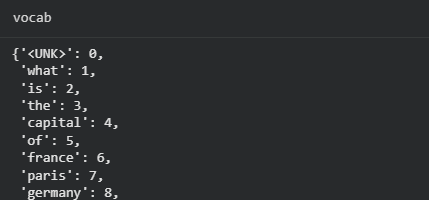

In [24]:
# Convert text to numerical indices
def text_to_indices(text, vocab):
  indexed_text = []
  for token in tokenize(text):
    if token in vocab:
      indexed_text.append(vocab[token])
    else:
      indexed_text.append(vocab['<UNK>'])
  return indexed_text

In [27]:
text_to_indices("What is the capital of India", vocab)

[1, 2, 3, 4, 5, 73]

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
  def __init__(self, df, vocab):
    self.df = df
    self.vocab = vocab

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, index):
    # Convert Question & Answer to indices
    numerical_question = text_to_indices(self.df.iloc[index]['question'], self.vocab)
    numerical_answer = text_to_indices(self.df.iloc[index]['answer'], self.vocab)

    return torch.tensor(numerical_question), torch.tensor(numerical_answer)

In [29]:
dataset = CustomDataset(df, vocab)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [31]:
dataset[5]

(tensor([10, 29,  3, 30, 31]), tensor([32]))

In [32]:
import torch.nn as nn
class RNN(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim=50)
    self.rnn = nn.RNN(50, 64, batch_first=True)
    self.fc = nn.Linear(64, vocab_size)

  def forward(self, question):
    embedded_question = self.embedding(question)
    hidden, final = self.rnn(embedded_question)
    output = self.fc(final.squeeze(0))
    return output

In [42]:
x = nn.Embedding(324, embedding_dim=50)
y = nn.RNN(50, 64, batch_first=True)
z = nn.Linear(64, 324)

print(dataset[0][0].shape)
a = dataset[0][0].unsqueeze(0)
print(a.shape)
b = x(a)
print(b.shape)
c, d = y(b)
print(c.shape, d.shape)
e = z(d.squeeze(0))
print(e.shape)

torch.Size([6])
torch.Size([1, 6])
torch.Size([1, 6, 50])
torch.Size([1, 6, 64]) torch.Size([1, 1, 64])
torch.Size([1, 324])


In [44]:
learning_rate = 0.001
epochs = 25

model = RNN(len(vocab))
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
  total_loss = 0
  for question, answer in dataloader:
    optimizer.zero_grad()
    output = model(question)
    loss = loss_function(output, answer[0])
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(f"Epoch: {epoch+1}, Loss: {total_loss/len(dataloader)}")

Epoch: 1, Loss: 5.827623081207276
Epoch: 2, Loss: 5.119470289018419
Epoch: 3, Loss: 4.263634763823616
Epoch: 4, Loss: 3.5481105513042874
Epoch: 5, Loss: 2.967595557371775
Epoch: 6, Loss: 2.429502590497335
Epoch: 7, Loss: 1.9293936020798153
Epoch: 8, Loss: 1.5031206707159679
Epoch: 9, Loss: 1.1443851153055826
Epoch: 10, Loss: 0.8756109641657935
Epoch: 11, Loss: 0.665295985672209
Epoch: 12, Loss: 0.5206377524468634
Epoch: 13, Loss: 0.4112987567981084
Epoch: 14, Loss: 0.336182130045361
Epoch: 15, Loss: 0.27534906855887836
Epoch: 16, Loss: 0.22825369876292018
Epoch: 17, Loss: 0.1921399827632639
Epoch: 18, Loss: 0.1638523783120844
Epoch: 19, Loss: 0.13973620558778446
Epoch: 20, Loss: 0.12223156996899182
Epoch: 21, Loss: 0.10642952935563194
Epoch: 22, Loss: 0.0935905233439472
Epoch: 23, Loss: 0.0825086187157366
Epoch: 24, Loss: 0.07378045564724339
Epoch: 25, Loss: 0.06644328865740035


In [46]:
from pandas.core.indexes.base import Index
def predict(model, question, threshold=0.5):
  # convert question to numbers
  numerical_question = text_to_indices(question, vocab)
  # tensor
  question_tensor = torch.tensor(numerical_question).unsqueeze(0)
  # predict
  output = model(question_tensor)
  # Convert logits to probs
  probs = torch.nn.functional.softmax(output, dim=1)
  # find index of max prob
  value, index = torch.max(probs, dim=1)

  if value < threshold:
    print("I don't know the answer to that question")

  print(list(vocab.keys())[index])

In [51]:
predict(model, "What is the largest planet in our solar system?")

jupiter


In [52]:
predict(model, "What is the capital of France?")

paris


In [54]:
predict(model, "What is the capital city of the country France?")

paris


In [55]:
predict(model, "What is the capital of India?")

delhi


In [56]:
predict(model, "Who painted mona lisa")

leonardo-da-vinci


In [57]:
predict(model, "hardest substance on earth?")

diamond
